## Checking of Energy Minimization

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Load data, skipping lines starting with '@' and '#'
# unpack=True allows you to assign columns directly to x and y
x, y = np.loadtxt("em_potential.xvg", comments=["@", "#"], unpack=True)

plt.plot(x, y)
plt.title("Potential Energy vs Steps")
plt.xlabel("Steps")
plt.ylabel("Potential Energy (kJ/mol)")
plt.ylim(-1500000, 1000000)  # Set y-axis limits for better visualization
plt.show()

FileNotFoundError: em_potential.xvg not found.

## Equilibration Plots

In [ ]:
import subprocess
import glob
import os
import numpy as np
import matplotlib.pyplot as plt

sim_dir = os.path.dirname(os.path.abspath("step6.1.xtc"))  # notebook working dir

# Derive .edr files from .xtc files (gmx energy reads .edr, not .xtc)
xtc_files = sorted(glob.glob("step6.*.xtc"))
edr_files = [f.replace(".xtc", ".edr") for f in xtc_files]

all_time = []
all_temp = []
all_press = []
step_labels = []

for edr_file, xtc_file in zip(edr_files, xtc_files):
    if not os.path.exists(edr_file):
        print(f"Warning: {edr_file} not found, skipping.")
        continue

    step_name = os.path.splitext(edr_file)[0]  # e.g. "step6.1"
    xvg_file = f"{step_name}_tp.xvg"

    result = subprocess.run(
        ["gmx", "energy", "-f", edr_file, "-o", xvg_file],
        input=b"Temperature\nPressure\n0\n",
        capture_output=True,
    )

    if result.returncode != 0:
        print(f"gmx energy failed for {edr_file}:")
        print(result.stderr.decode(errors="replace"))
        continue
    else:
        print(f"Processed {edr_file} -> {xvg_file}")

    # xvg columns: time, Temperature, Pressure
    try:
        data = np.loadtxt(xvg_file, comments=["@", "#"], unpack=True)
    except Exception as e:
        print(f"Could not load {xvg_file}: {e}")
        continue

    all_time.append(data[0])
    all_temp.append(data[1])
    all_press.append(data[2])
    step_labels.append(step_name)

print(f"\nLoaded data for steps: {step_labels}")


Processed step6.1.edr -> step6.1_tp.xvg
Processed step6.2.edr -> step6.2_tp.xvg
Processed step6.3.edr -> step6.3_tp.xvg
Processed step6.4.edr -> step6.4_tp.xvg
Processed step6.5.edr -> step6.5_tp.xvg
Processed step6.6.edr -> step6.6_tp.xvg

Loaded data for steps: ['step6.1', 'step6.2', 'step6.3', 'step6.4', 'step6.5', 'step6.6']


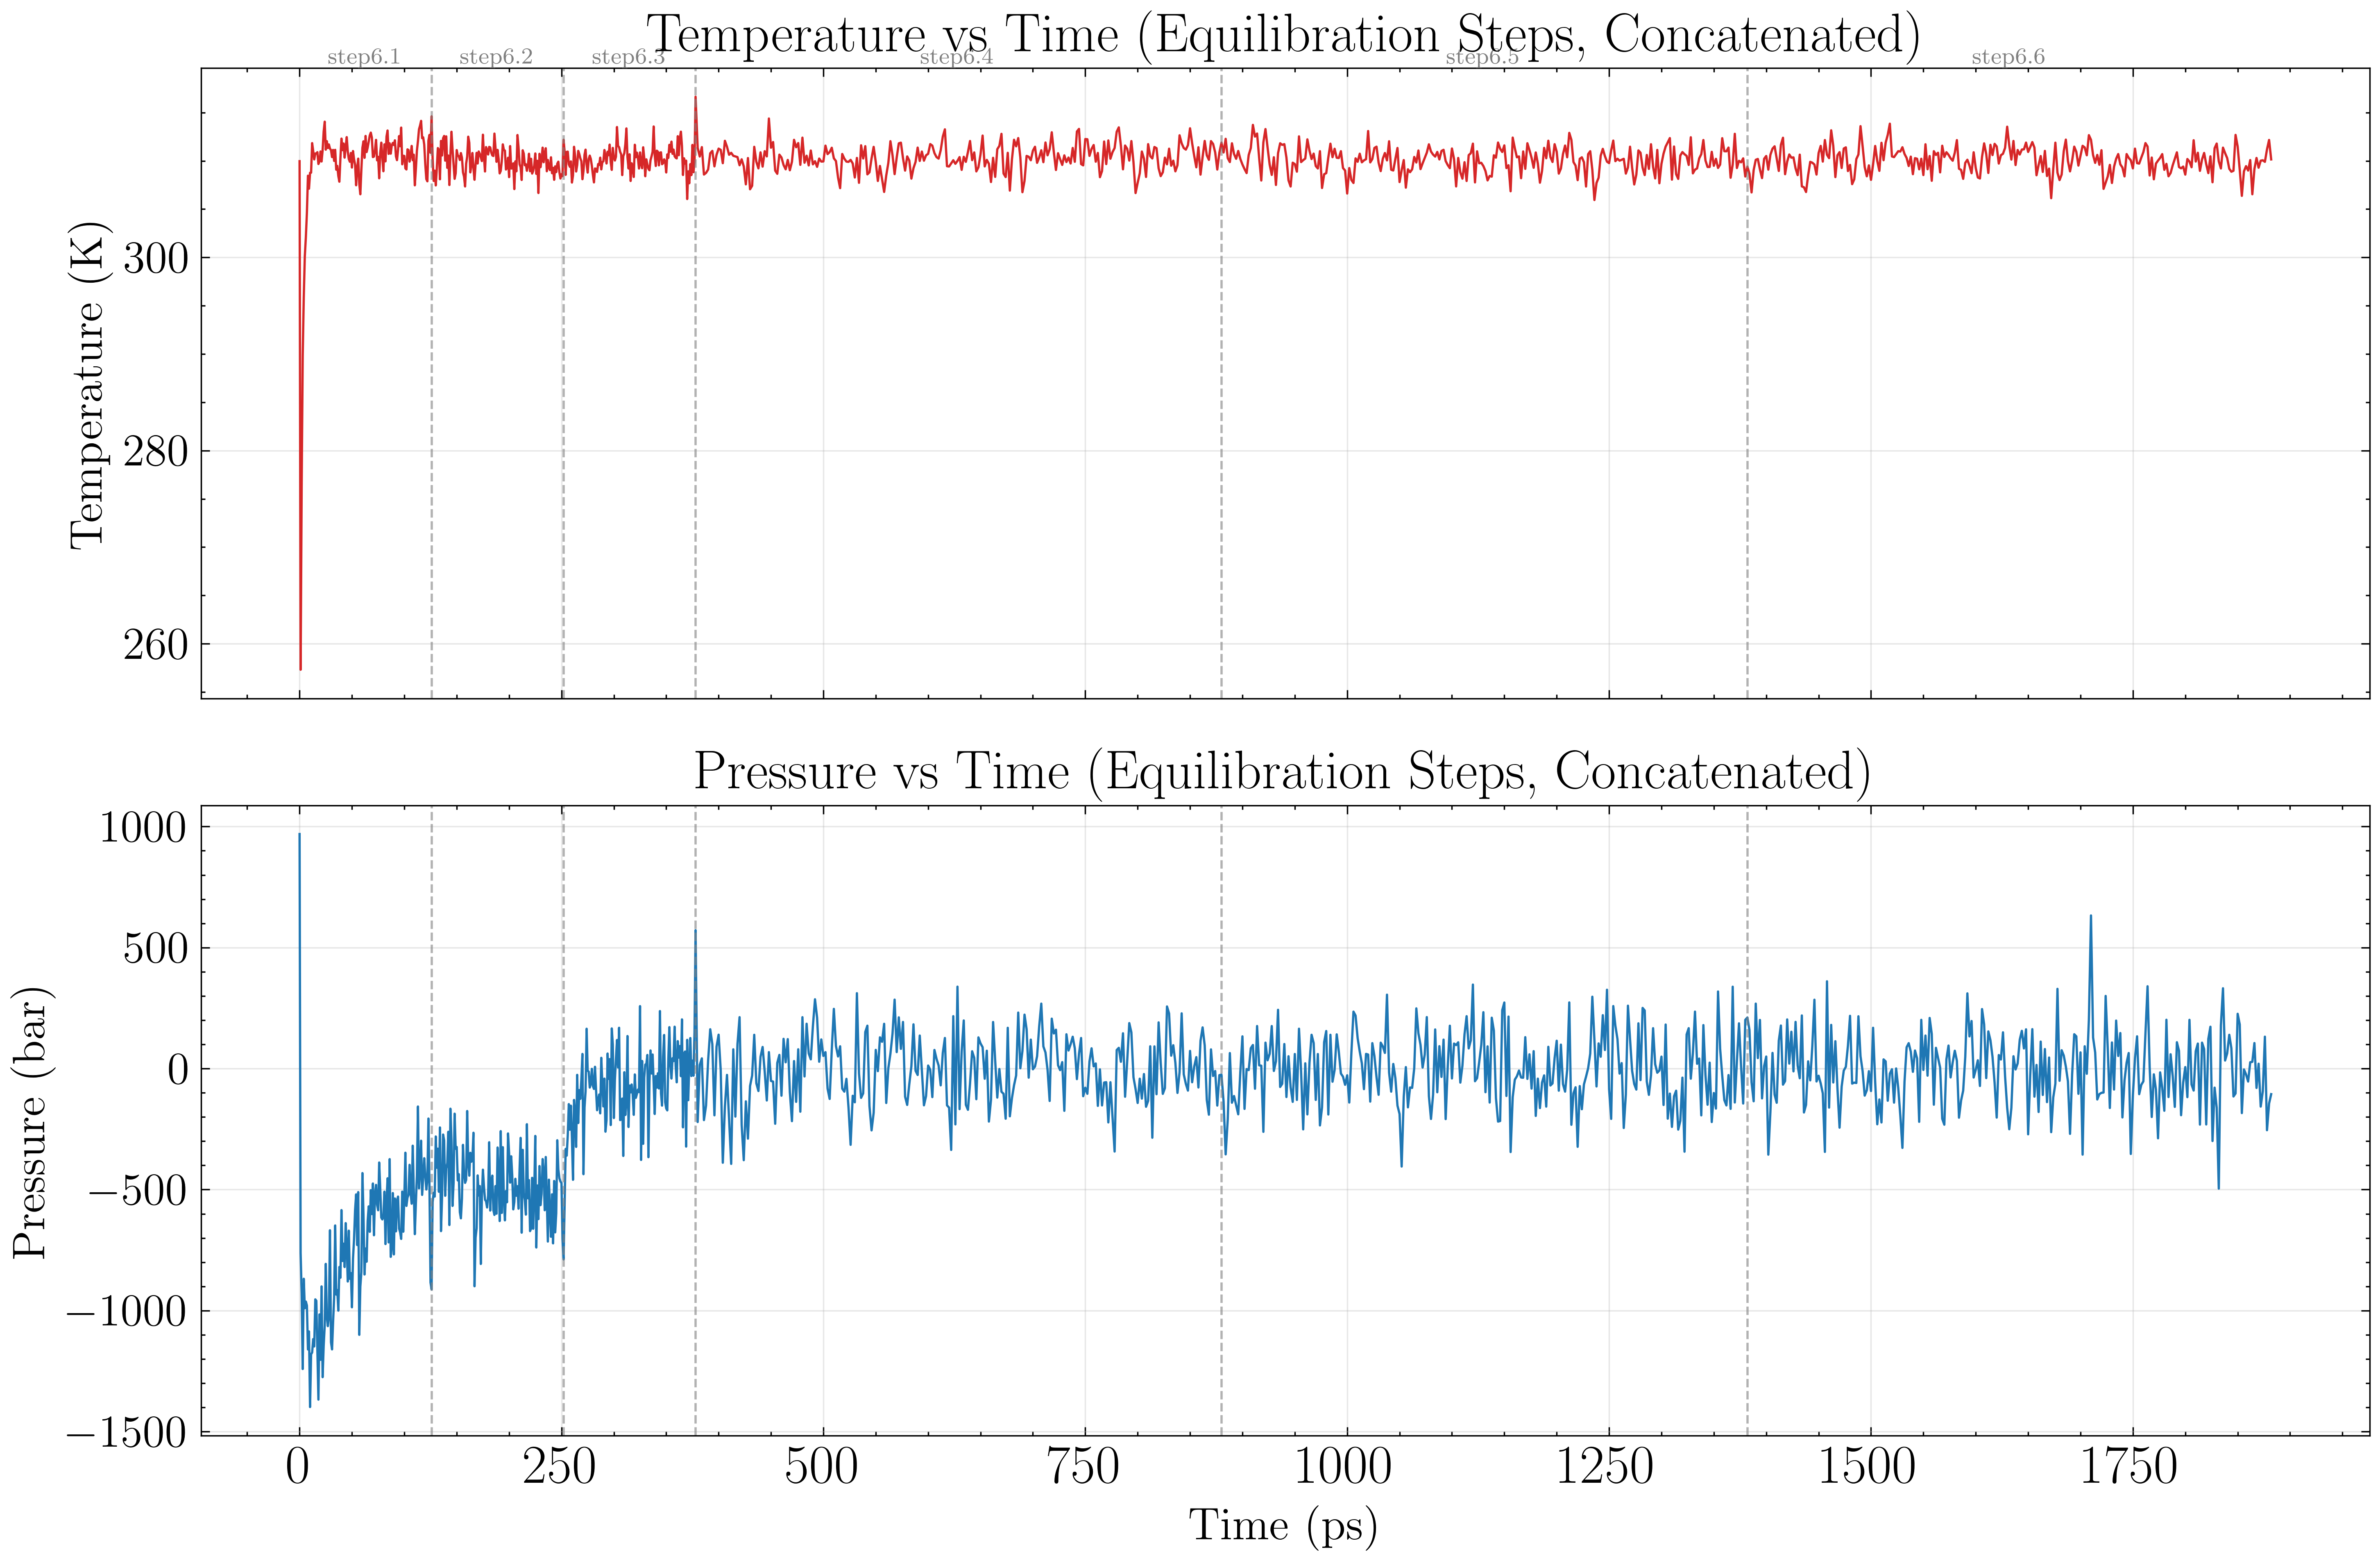

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots

plt.style.use("science")

# Concatenate consecutive steps into a single continuous time series
# Offset each step's time so it follows the previous one
concat_time = []
concat_temp = []
concat_press = []
time_offset = 0.0

for time, temp, press in zip(all_time, all_temp, all_press):
    concat_time.append(time + time_offset)
    concat_temp.append(temp)
    concat_press.append(press)
    time_offset += time[-1] - time[0] + (time[1] - time[0])  # advance by step duration + dt

concat_time = np.concatenate(concat_time)
concat_temp = np.concatenate(concat_temp)
concat_press = np.concatenate(concat_press)

# Add vertical lines at step boundaries
step_boundaries = []
t_offset = 0.0
for time in all_time[:-1]:
    t_offset += time[-1] - time[0] + (time[1] - time[0])
    step_boundaries.append(t_offset)

fig, (ax_temp, ax_press) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax_temp.plot(concat_time, concat_temp, lw=0.8, color="tab:red")
ax_press.plot(concat_time, concat_press, lw=0.8, color="tab:blue")

for bnd in step_boundaries:
    ax_temp.axvline(bnd, color="gray", lw=0.8, ls="--", alpha=0.6)
    ax_press.axvline(bnd, color="gray", lw=0.8, ls="--", alpha=0.6)

# Annotate step labels at the top of the temperature plot
t_offset = 0.0
for i, (time, label) in enumerate(zip(all_time, step_labels)):
    mid = t_offset + (time[-1] - time[0]) / 2
    ax_temp.text(mid, ax_temp.get_ylim()[1], label, ha="center", va="bottom",
                 fontsize=8, color="gray")
    t_offset += time[-1] - time[0] + (time[1] - time[0])

ax_temp.set_title("Temperature vs Time (Equilibration Steps, Concatenated)")
ax_temp.set_ylabel("Temperature (K)")
ax_temp.grid(True, alpha=0.3)

ax_press.set_title("Pressure vs Time (Equilibration Steps, Concatenated)")
ax_press.set_xlabel("Time (ps)")
ax_press.set_ylabel("Pressure (bar)")
ax_press.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Box vectors

It is also advisable to verify that the box vectors have stabilized, ensuring a stable lateral area of the membrane (Box-X and Box-Y).

Note that box vectors only change during NPT ensemble dynamics. in NVT ensemble, all boundary conditions are fixed by definition.

Processed step6.3.edr -> step6.3_box.xvg
Processed step6.4.edr -> step6.4_box.xvg
Processed step6.5.edr -> step6.5_box.xvg
Processed step6.6.edr -> step6.6_box.xvg


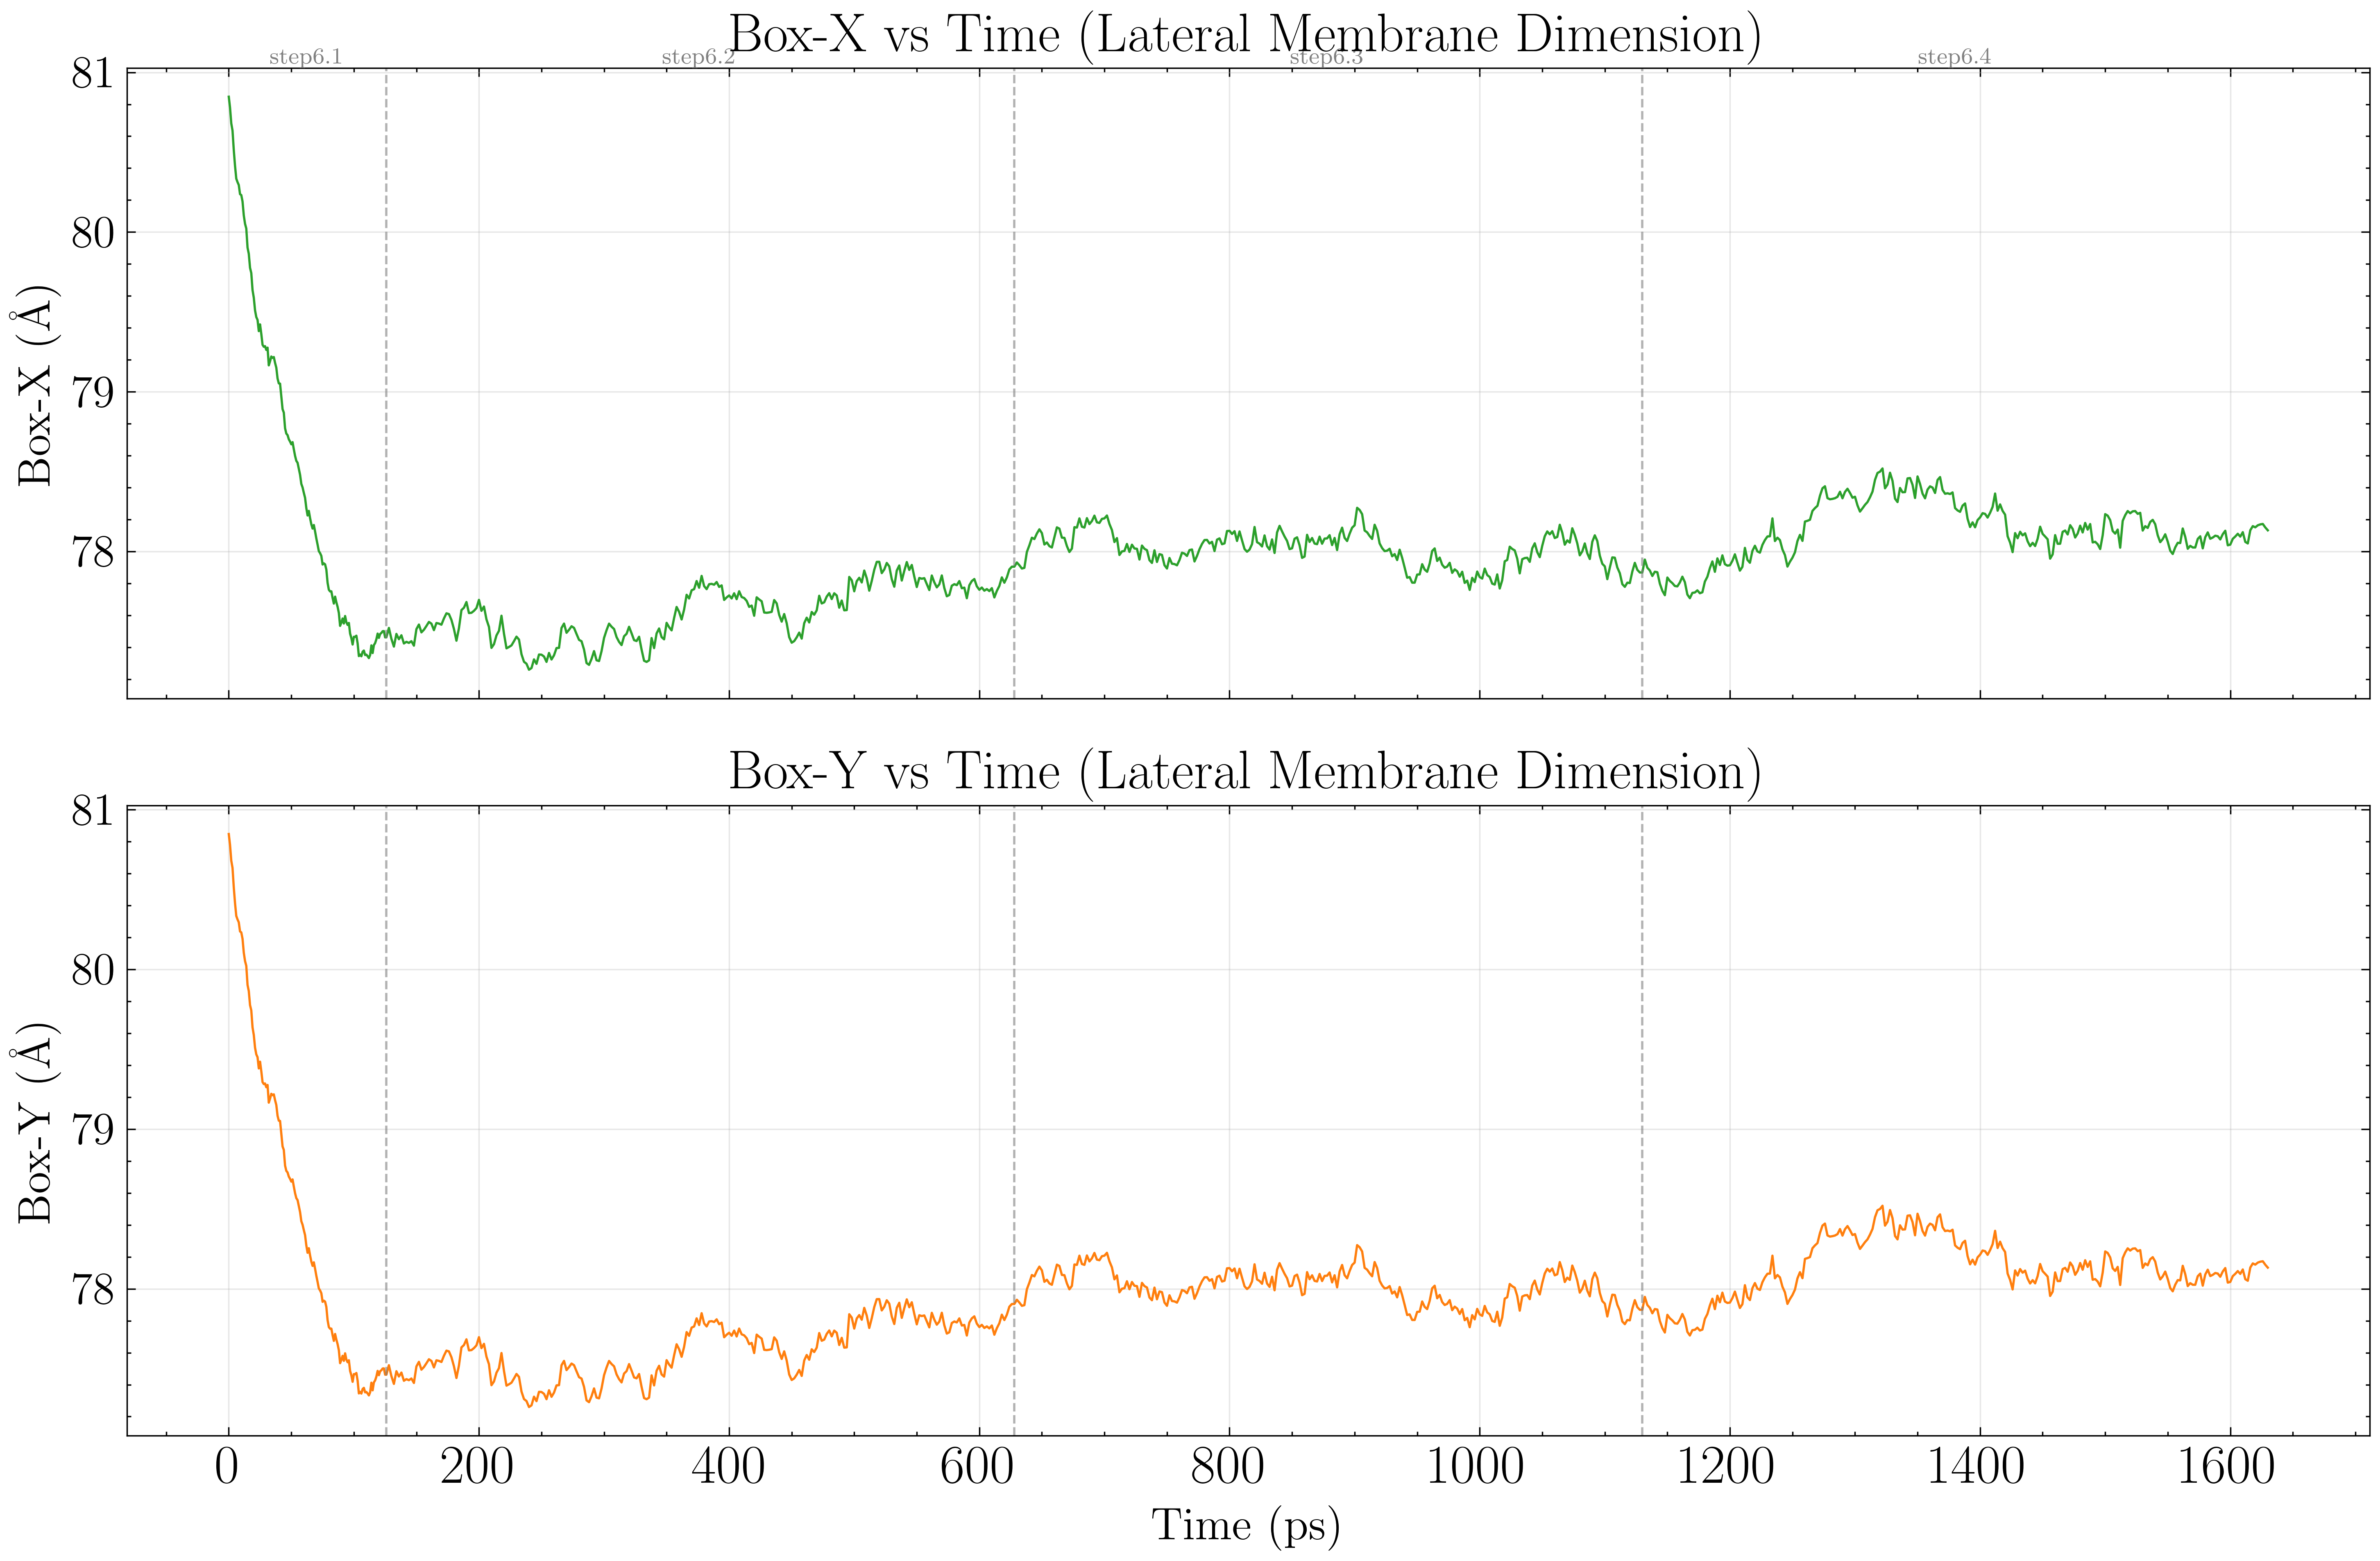

In [ ]:
import subprocess
import os
import numpy as np
import matplotlib.pyplot as plt
import scienceplots

plt.style.use("science")
# Extract Box-X and Box-Y from each equilibration step .edr file
all_box_time = []
all_boxx = []
all_boxy = []

for edr_file in edr_files[2:]:
    step_name = os.path.splitext(edr_file)[0]
    xvg_file = f"{step_name}_box.xvg"

    result = subprocess.run(
        ["gmx", "energy", "-f", edr_file, "-o", xvg_file],
        input=b"Box-X\nBox-Y\n0\n",
        capture_output=True,
    )

    if result.returncode != 0:
        print(f"gmx energy failed for {edr_file}:")
        print(result.stderr.decode(errors="replace"))
        continue
    else:
        print(f"Processed {edr_file} -> {xvg_file}")

    try:
        data = np.loadtxt(xvg_file, comments=["@", "#"], unpack=True)
    except Exception as e:
        print(f"Could not load {xvg_file}: {e}")
        continue

    # data[0]=time (ps), data[1]=Box-X (nm), data[2]=Box-Y (nm)
    all_box_time.append(data[0])
    all_boxx.append(data[1])
    all_boxy.append(data[2])

# Build concatenated time axis independently for box data
concat_box_time = []
box_time_offset = 0.0
for t in all_box_time:
    dt = t[1] - t[0] if len(t) > 1 else 0.0
    concat_box_time.append(t + box_time_offset)
    box_time_offset += t[-1] - t[0] + dt

concat_box_time = np.concatenate(concat_box_time)
concat_boxx = np.concatenate(all_boxx)
concat_boxy = np.concatenate(all_boxy)

# Step boundary positions on this time axis
box_boundaries = []
t_off = 0.0
for t in all_box_time[:-1]:
    dt = t[1] - t[0] if len(t) > 1 else 0.0
    t_off += t[-1] - t[0] + dt
    box_boundaries.append(t_off)

# Plot
fig, (ax_x, ax_y) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax_x.plot(concat_box_time, concat_boxx * 10, lw=0.8, color="tab:green")   # nm -> Å
ax_y.plot(concat_box_time, concat_boxy * 10, lw=0.8, color="tab:orange")

for bnd in box_boundaries:
    ax_x.axvline(bnd, color="gray", lw=0.8, ls="--", alpha=0.6)
    ax_y.axvline(bnd, color="gray", lw=0.8, ls="--", alpha=0.6)

# Step labels
t_off = 0.0
for t, label in zip(all_box_time, step_labels):
    dt = t[1] - t[0] if len(t) > 1 else 0.0
    mid = t_off + (t[-1] - t[0]) / 2
    ax_x.text(mid, ax_x.get_ylim()[1], label, ha="center", va="bottom",
              fontsize=8, color="gray")
    t_off += t[-1] - t[0] + dt

ax_x.set_title("Box-X vs Time (Lateral Membrane Dimension)")
ax_x.set_ylabel("Box-X (Å)")
ax_x.grid(True, alpha=0.3)

ax_y.set_title("Box-Y vs Time (Lateral Membrane Dimension)")
ax_y.set_xlabel("Time (ps)")
ax_y.set_ylabel("Box-Y (Å)")
ax_y.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Production PP

First, let's test to ensure that the concatenation worked.

In [1]:
import os
data_dir = os.environ.get("HOME", "/home/daneel")
data_dir = os.path.join(data_dir, "gitrepos/gromacs_sims/Antimicrobial_Peptides/Ku04AMP01_Membrane_Bilayer/simulation")



In [2]:
import MDAnalysis as mda
from MDAnalysis.analysis import rms
import matplotlib.pyplot as plt
#plt.rcParams['text.usetex'] = False
import scienceplots
plt.style.use("science")

u = mda.Universe(os.path.join(data_dir, "step7_1.tpr"), os.path.join(data_dir, "traj_prod.xtc"),os.path.join(data_dir, "step7_11_100ns.part0002.xtc"))
#u = mda.Universe(os.path.join(data_dir, "traj_dry.tpr"), os.path.join(data_dir, "traj_dry.xtc"))

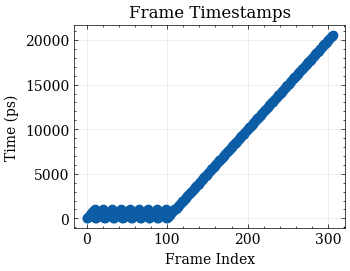

Min dt: -1000.00 ps, Max dt: 100.00 ps
Monotonically increasing: False
Total frames: 307, Time range: 0.00 – 20600.00 ps


In [4]:
# First, check the timestamps for each frame
timestamps = [ts.time for ts in u.trajectory]  # in ps
plt.rcParams['text.usetex'] = False

plt.plot(timestamps, marker="o", linestyle="")
plt.title("Frame Timestamps")
plt.xlabel("Frame Index")
plt.ylabel("Time (ps)")
plt.grid(True, alpha=0.3)
plt.show()

# Check if timestamps are monotonically increasing (expected after correct trjcat)
import numpy as np
diffs = np.diff(timestamps)
print(f"Min dt: {diffs.min():.2f} ps, Max dt: {diffs.max():.2f} ps")
print(f"Monotonically increasing: {np.all(diffs > 0)}")
print(f"Total frames: {len(timestamps)}, Time range: {timestamps[0]:.2f} – {timestamps[-1]:.2f} ps")

The concatenation clearly failed — timestamps repeat from 0–10000 ps about 10 times instead of being continuous. This is a classic trjcat issue where it concatenated the files but didn't offset the timestamps.


Fix the timestamps in Python without re-running gromacs:

In [5]:
# Refined timestamp logic
total_actual_time = 30000.0  # The physical simulation time in ps (30 ns)
n_frames = len(u.trajectory)

# Create a linear mapping from 0 to 10000 ps across the existing frames
corrected_times = np.linspace(0, total_actual_time, n_frames)

print(f"Total Frames: {n_frames}")
print(f"Mapped Time Range: {corrected_times[0]:.0f} to {corrected_times[-1]:.0f} ps")

Total Frames: 307
Mapped Time Range: 0 to 30000 ps


## Verify that membrane is oriented with z-axis vertical


Although this is standard convention, we **should** check this.


The definitive check is a number density profile — if z is the normal, you'll see distinct layers (water → LPS headgroups → acyl chains → phospholipid headgroups → water) along z but not along x or y. Add this cell to confirm:

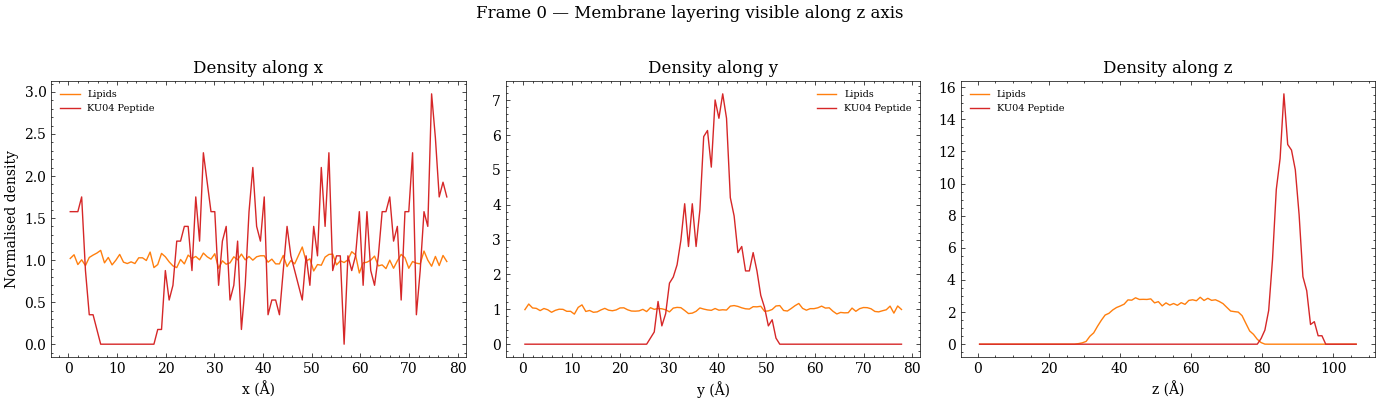

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
plt.style.use("science")
plt.rcParams['text.usetex'] = False
u.trajectory[0]
bins = 100

# Updated selections based on topol.top
sel_lip = u.select_atoms("resindex 36-235")
sel_ku04 = u.select_atoms("resindex 0-35")

box = u.dimensions[:3] # Å

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
labels = ["x", "y", "z"]

# Components to plot
components = [
    (sel_lip, "Lipids", "tab:orange"),
    (sel_ku04, "KU04 Peptide", "tab:red"),
]

for col, (ax, dim) in enumerate(zip(axes, range(3))):
    for ag, name, color in components:
        if len(ag) == 0:
            continue
        
        pos = ag.positions[:, dim]
        counts, edges = np.histogram(pos, bins=bins, range=(0, box[dim]))
        centres = 0.5 * (edges[:-1] + edges[1:])
        
        # Avoid division by zero if a component is missing in a specific plane (unlikely for density)
        if counts.max() > 0:
            ax.plot(centres, counts / counts.mean(), label=name, lw=1.0, color=color)

    ax.set_xlabel(f"{labels[col]} (Å)")
    ax.set_ylabel("Normalised density" if col == 0 else "")
    #ax.set_ylim(0, 1.5)
    ax.set_title(f"Density along {labels[col]}")
    ax.legend(fontsize=7)

plt.suptitle("Frame 0 — Membrane layering visible along z axis", y=1.02)
plt.tight_layout()
plt.show()

The lipid layers are uniform in x and y, and the ku04 shows a spike in z above the lipids. As expected.

## Get RMSDs

- **Old code (no superposition)**: RMSD starts at ~138 Å and stays 138–145 Å — the entire signal is a **PBC artifact**. The membrane's center of mass jumped across the periodic box at some point (very common with broken `trjcat` trajectories), so the raw atom-to-atom distances are dominated by that ~138 Å offset, not by conformational changes.

- **New code (`superposition=True`)**: Least-squares fits (translates + rotates) the membrane onto the reference before computing RMSD, removing the rigid-body offset. The result (0–30 Å) is the actual conformational RMSD.

So the old plot was physically meaningless. The new one is correct.

That said, the spikiness in the new plot is still a concern — it's a sign of residual PBC imaging issues (individual molecules jumping across box boundaries within the concatenated trajectory). For a membrane, the standard fix is to also **unwrap** molecules per-frame before computing RMSD: 

The `transformations.unwrap` call fixes atoms that jump across the periodic boundary mid-trajectory, which is what causes those sharp spikes. It runs on-the-fly for each frame without modifying the file on disk.

Made changes.

In [7]:
from multiprocessing import Pool, cpu_count
from functools import partial
from MDAnalysis.analysis import rms
from MDAnalysis import transformations as trans
from tqdm.notebook import tqdm
import numpy as np
# --- Config ---
tpr_file = os.path.join(data_dir, "step7_1.tpr")
xtc_file = os.path.join(data_dir, "traj_prod.xtc")
xtc_file2 = os.path.join(data_dir, "step7_11_100ns.part0002.xtc")

ku04_sel = "resindex 0-35"
memb_sel = "resindex 36-235"
# Reload universe with center_in_box + wrap (no unwrap: that needs sequential
# reads from frame 0 and is incompatible with block-parallel random access).
# traj_whole.xtc is already molecule-whole, so this is sufficient.
u = mda.Universe(tpr_file, xtc_file, xtc_file2)
membrane = u.select_atoms(memb_sel)
ku04     = u.select_atoms(ku04_sel)
workflow = [
    trans.center_in_box(membrane, wrap=True),
    trans.wrap(u.select_atoms("all"), compound="residues"),
]
u.trajectory.add_transformations(*workflow)

# Reference = frame 0 after imaging
u.trajectory[0]
ref_memb = membrane.positions.copy()
ref_ku04  = ku04.positions.copy()

# --- Split trajectory into blocks (one per core) ---
n_jobs   = min(cpu_count(), 8)
n_frames = u.trajectory.n_frames
n_fpb    = n_frames // n_jobs   # frames per block
blocks   = [range(i * n_fpb, (i + 1) * n_fpb) for i in range(n_jobs - 1)]
blocks.append(range((n_jobs - 1) * n_fpb, n_frames))
print(f"Frames: {n_frames}  |  Cores: {n_jobs}  |  ~{n_fpb} frames/block")

# --- Worker function ---
def rmsd_block(block_frames, tpr_file, xtc_file, xtc_file2, memb_sel, ku04_sel, ref_memb, ref_ku04):
    """Each worker loads its own Universe and iterates its slice sequentially."""
    import MDAnalysis as mda
    from MDAnalysis.analysis import rms
    from MDAnalysis import transformations as trans

    u_w    = mda.Universe(tpr_file, xtc_file, xtc_file2)
    memb_w = u_w.select_atoms(memb_sel)
    ku04_w = u_w.select_atoms(ku04_sel)
    wf = [
        trans.center_in_box(memb_w, wrap=True),
        trans.wrap(u_w.select_atoms("all"), compound="residues"),
    ]
    u_w.trajectory.add_transformations(*wf)

    res_memb, res_ku04 = [], []
    for _ in u_w.trajectory[block_frames.start:block_frames.stop]:
        res_memb.append(rms.rmsd(memb_w.positions, ref_memb, superposition=True))
        res_ku04.append(rms.rmsd(ku04_w.positions,  ref_ku04,  superposition=True))
    u_w.trajectory.close() # Explicitly close to avoid __del__ race    
    return res_memb, res_ku04

# --- Run in parallel ---
run_block = partial(rmsd_block,
                    tpr_file=tpr_file, xtc_file=xtc_file, xtc_file2=xtc_file2,
                    memb_sel=memb_sel, ku04_sel=ku04_sel,
                    ref_memb=ref_memb, ref_ku04=ref_ku04)

with Pool(n_jobs) as pool:
    block_results = list(tqdm(pool.imap(run_block, blocks),
                            total=n_jobs, desc="Blocks", unit="block"))

# --- Combine in order ---
rmsd_memb = [v for memb_res, _       in block_results for v in memb_res]
rmsd_ku04  = [v for _,       ku04_res  in block_results for v in ku04_res]
print(f"Done. {len(rmsd_memb)} RMSD values computed.")



/usr/local/lib/python3.12/site-packages/Bio/Application/__init__.py:39: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(


Frames: 307  |  Cores: 8  |  ~38 frames/block


Blocks:   0%|          | 0/8 [00:00<?, ?block/s]

Done. 307 RMSD values computed.


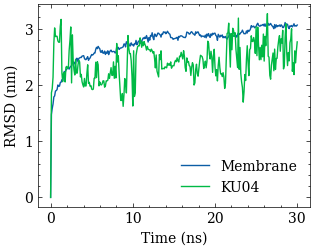

In [9]:
import scienceplots
plt.style.use("science")
plt.rcParams['text.usetex'] = False

plt.plot(corrected_times/1000, np.array(rmsd_memb)/10, label="Membrane")
plt.plot(corrected_times/1000, np.array(rmsd_ku04)/10, label="KU04")
plt.legend()
plt.xlabel("Time (ns)")
plt.ylabel("RMSD (nm)")
#plt.grid(True, alpha=0.6)
plt.show()

In [11]:
print(f"Atoms: {len(ku04)}")
print(f"Resnames: {np.unique(ku04.resnames)}")

Atoms: 571
Resnames: ['ALA' 'ARG' 'ASN' 'ASP' 'GLN' 'GLU' 'GLY' 'ILE' 'LYS' 'PRO' 'SER' 'THR'
 'TYR' 'VAL']


## Peptide center-of-mass depth (MOST IMPORTANT)

This is the primary penetration metric.

Measure:

COM of PMBN
vs
membrane midplane (or phosphate plane).

Plot:

z_peptide(t) - z_membrane_center(t)

Interpretation:

* constant near-water value → no binding

* stable near-headgroup region → adsorption

* gradual inward motion → insertion

* crossing midplane → translocation

### Get headgroup distance 

You can verify the exact headgroup positions for your specific system by calculating the Z-position of the Phosphorus (P) atoms relative to the midplane.

In GROMACS/CHARMM36, Phosphorus atoms (name P) are located in the headgroups of all your lipids (PMPE, POPE, PYPG, etc.). By tracking their COM, you get the objective "surface" of the membrane.

In [12]:
# Selection for all phosphorus atoms in the membrane
phosphorus_sel = "(resindex 36-235) and name P"

def p_depth_block(block_frames, tpr_file, xtc_file, xtc_file2, memb_sel, p_sel):
    import MDAnalysis as mda
    from MDAnalysis import transformations as trans
    u_w = mda.Universe(tpr_file, xtc_file, xtc_file2)
    memb_w = u_w.select_atoms(memb_sel)
    p_w = u_w.select_atoms(p_sel)
    
    # Imaging
    wf = [trans.center_in_box(memb_w, wrap=True), trans.wrap(u_w.atoms)]
    u_w.trajectory.add_transformations(*wf)

    z_p_upper, z_p_lower, z_mid = [], [], []
    for _ in u_w.trajectory[block_frames.start:block_frames.stop]:
        mid = memb_w.center_of_mass()[2]
        p_pos = p_w.positions[:, 2]
        
        # Split P atoms into upper and lower based on midplane
        z_p_upper.append(p_pos[p_pos > mid].mean())
        z_p_lower.append(p_pos[p_pos < mid].mean())
        z_mid.append(mid)
        
    u_w.trajectory.close()
    return z_p_upper, z_p_lower, z_mid

# Run in parallel (reuse your blocks and n_jobs)
run_p = partial(p_depth_block, tpr_file=tpr_file, xtc_file=xtc_file, xtc_file2=xtc_file2,
                memb_sel=memb_sel, p_sel=phosphorus_sel)

with Pool(n_jobs) as pool:
    p_results = list(tqdm(pool.imap(run_p, blocks), total=n_jobs, desc="P-depth"))

# Average distances from midplane
dz_p_upper = np.array([v for r in p_results for v in r[0]]) - np.array([v for r in p_results for v in r[2]])
dz_p_lower = np.array([v for r in p_results for v in r[1]]) - np.array([v for r in p_results for v in r[2]])

print(f"Verified Phosphorus Planes: {dz_p_upper.mean():.2f} Å and {dz_p_lower.mean():.2f} Å")

P-depth:   0%|          | 0/8 [00:00<?, ?it/s]

Verified Phosphorus Planes: 19.32 Å and -19.31 Å


### Get z-COM of peptide

In [13]:
import numpy as np
from tqdm.notebook import tqdm
from functools import partial
from multiprocessing import Pool

# Update selections for the current system
ku04_sel = "resindex 0-35"
memb_sel = "resindex 36-235"

def depth_block(block_frames, tpr_file, xtc_file,xtc_file2, memb_sel, ku04_sel):
    """Worker: z-COM of KU04 and membrane midplane per frame."""
    import MDAnalysis as mda
    from MDAnalysis import transformations as trans

    u_w     = mda.Universe(tpr_file, xtc_file, xtc_file2)
    memb_w  = u_w.select_atoms(memb_sel)
    ku04_w  = u_w.select_atoms(ku04_sel)
    
    # Standard imaging to ensure COM calculations aren't broken by PBC
    wf = [
        trans.center_in_box(memb_w, wrap=True),
        trans.wrap(u_w.atoms, compound="residues"),
    ]
    u_w.trajectory.add_transformations(*wf)

    z_ku04, z_mid = [], []
    for _ in u_w.trajectory[block_frames.start:block_frames.stop]:
        z_mid.append(memb_w.center_of_mass()[2])
        z_ku04.append(ku04_w.center_of_mass()[2])
        
    u_w.trajectory.close()
    return z_ku04, z_mid

# Prepare partial function for parallel execution
run_depth = partial(depth_block,
                    tpr_file=tpr_file, xtc_file=xtc_file, xtc_file2=xtc_file2,
                    memb_sel=memb_sel, ku04_sel=ku04_sel)

print(f"Computing penetration depth on {n_jobs} cores …")
with Pool(n_jobs) as pool:
    depth_results = list(tqdm(pool.imap(run_depth, blocks),
                            total=n_jobs, desc="Blocks", unit="block"))

# Combine results
z_ku04 = np.array([v for r in depth_results for v in r[0]])
z_mid  = np.array([v for r in depth_results for v in r[1]])

# Depth relative to membrane midplane
# (positive = upper leaflet side, negative = lower leaflet side)
dz_ku04 = z_ku04 - z_mid

print(f"Done. Mean KU04 depth relative to midplane: {dz_ku04.mean():.1f} Å")

Computing penetration depth on 8 cores …


Blocks:   0%|          | 0/8 [00:00<?, ?block/s]

Done. Mean KU04 depth relative to midplane: 30.4 Å


### Plot z-COM relative to membrane COM and headgroup planes

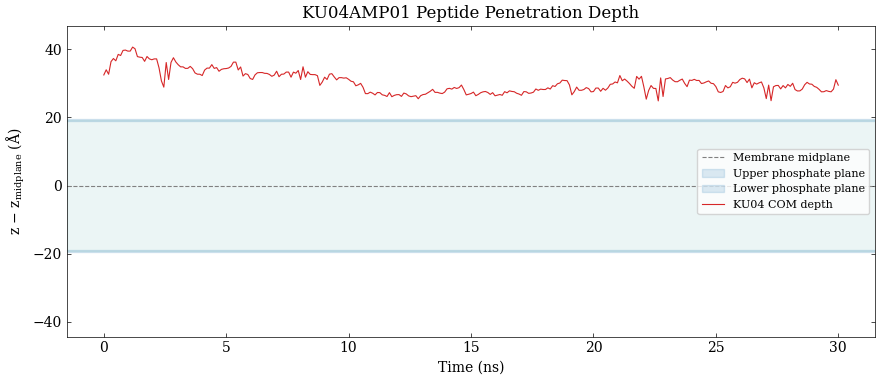

In [14]:
import matplotlib.pyplot as plt
import scienceplots
plt.style.use("science")
plt.rcParams['text.usetex'] = False
t_ns = corrected_times / 1000

fig, ax = plt.subplots(figsize=(9, 4))

# Mark the membrane center line
ax.axhline(0, color="gray", lw=0.8, ls="--", label="Membrane midplane")

# UPDATED: Verified Phosphorus headgroup planes
upper_p = dz_p_upper.mean()
lower_p = dz_p_lower.mean()

upper_p_std = dz_p_upper.std()
lower_p_std = dz_p_lower.std()
ax.axhspan(upper_p - upper_p_std, upper_p + upper_p_std, alpha=0.15, color="tab:blue", label="Upper phosphate plane")
ax.axhspan(lower_p - lower_p_std, lower_p + lower_p_std, alpha=0.15, color="tab:blue", label="Lower phosphate plane")

ax.axhspan(lower_p, upper_p, alpha=0.08, color="teal")

# Plot the Peptide depth
ax.plot(t_ns, dz_ku04, lw=0.8, color="tab:red", label="KU04 COM depth")

ax.set_xlabel("Time (ns)")
ax.set_ylabel(r"z − z$_{\text{midplane}}$ (Å)")
ax.set_title("KU04AMP01 Peptide Penetration Depth")
ax.legend(loc="center right", fontsize=8, frameon=True, fancybox=True)
ax.minorticks_off()
ax.set_ylim(lower_p - 25, 1.15 * np.max(dz_ku04))
plt.tight_layout()
plt.show()

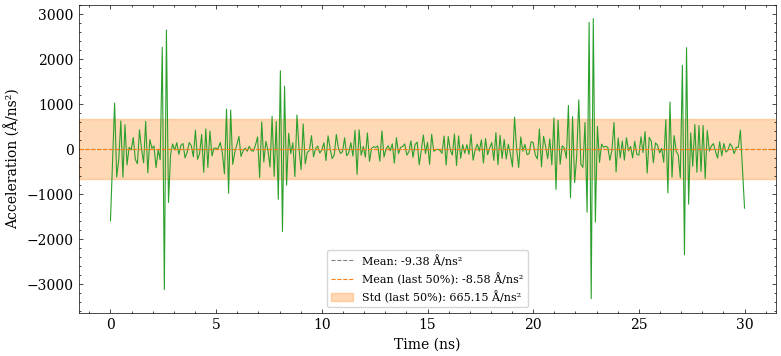

In [21]:
# Use scipy derivative functions to calculate z-penetration acceleration of KU04AMP01 peptide
from scipy.interpolate import UnivariateSpline
import matplotlib.pyplot as plt
import scienceplots
plt.style.use("science")
plt.rcParams['text.usetex'] = False
spline = UnivariateSpline(t_ns, dz_ku04, s=0)
fig, ax = plt.subplots(figsize=(9, 4))
dz_ku04_dt = spline.derivative(n=1)(t_ns)
dz_ku04_d2t = spline.derivative(n=2)(t_ns)
plt.plot(t_ns, dz_ku04_d2t, lw=0.8, color="tab:green")
# Time average shown as a horizontal line
plt.axhline(dz_ku04_d2t.mean(), color="gray", lw=0.8, ls="--", label=f"Mean: {dz_ku04_d2t.mean():.2f} Å/ns²")
#Fluctuations shown as a shaded rectangle
#plt.axhspan(dz_ku04_d2t.mean() - dz_ku04_d2t.std(), dz_ku04_d2t.mean() + dz_ku04_d2t.std(), color="gray", alpha=0.3, label=f"Std: {dz_ku04_d2t.std():.2f} Å/ns²")
plt.xlabel("Time (ns)")
plt.ylabel(r"Acceleration (Å/ns²)")

# Calculat mean and std over only the last 50% of the simulation
last_50_percent_mask = t_ns >= (t_ns[-1] - 0.5 * (t_ns[-1] - t_ns[0]))
mean_accel_last_50_percent = dz_ku04_d2t[last_50_percent_mask].mean()
std_accel_last_50_percent = dz_ku04_d2t[last_50_percent_mask].std()
plt.axhline(mean_accel_last_50_percent, color="tab:orange", lw=0.8, ls="--", label=f"Mean (last 50%): {mean_accel_last_50_percent:.2f} Å/ns²")
plt.axhspan(mean_accel_last_50_percent - std_accel_last_50_percent, mean_accel_last_50_percent + std_accel_last_50_percent, color="tab:orange", alpha=0.3, label=f"Std (last 50%): {std_accel_last_50_percent:.2f} Å/ns²")
#plt.title("KU04AMP01 Peptide Penetration Acceleration")
plt.legend(fontsize=8, frameon=True, fancybox=True)

Looks like gradual inward motion, followed by repulsion. Probably needs to run longer.